## Matemática e Estatística Aplicada Para Data Science, Machine Learning e IA
## Lista de Exercícios 9
### Distribuição Normal Para Resolver Problemas de Negócio

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## Exercício 1: Tempo de Produção

Suponha que o tempo de produção de um carro em uma fábrica siga uma distribuição normal com uma média de 20 horas e um desvio padrão de 2 horas.

Pergunta: Qual é a probabilidade de que um carro seja produzido em menos de 18 horas?

Usaremos a função cdf (função de distribuição cumulativa) do objeto norm da biblioteca SciPy para calcular a probabilidade de um carro ser produzido em menos de 18 horas. A função cdf retorna a área sob a curva da distribuição normal até o ponto especificado (neste caso, 18 horas), que representa a probabilidade acumulada.

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

In [8]:
from scipy import stats
import numpy as np

media = 20
desvio_padrao = 2
tempo_limite = 18 

print(" === TEMPO DE PRODUÇÃO DE CARROS === ")
print(f"Distribuição: Normal(μ={media}, σ={desvio_padrao})")
print(f"Pergunta: P(X < {tempo_limite} horas)")

probabilidade_cdf = stats.norm.cdf(tempo_limite, loc=media, scale=desvio_padrao)

print(f"\nCálculo:")
print(f"P(X < {tempo_limite}) = {probabilidade_cdf:.4f}")
print(f"Probabilidade: {probabilidade_cdf*100:.2f}%")

z_score = (tempo_limite - media) / desvio_padrao
print(f"\nZ-score = ({tempo_limite} - {media}) / {desvio_padrao} = {z_score}")
print(f"P(Z < {z_score}) = {probabilidade_cdf:.4f}")

print("\nInterpretação:")
print(f"Aproximadamente {probabilidade_cdf*100:.2f}% dos carros são produzidos em menos de {tempo_limite} horas")

print("\nVerificação (Simulado com 10.000 anos carros):")
tempos_simulados = np.random.normal(media, desvio_padrao, 10000)
carros_rapidos = np.sum(tempos_simulados < tempo_limite)
prob_simulada = carros_rapidos / 10000

print(f"Carros produzidos < {tempo_limite}h: {carros_rapidos}")
print(f"Probabilidade simulada: {prob_simulada:.4f} ({prob_simulada*100:.2f}%)")

print(f"\nProbabilidade(cdf): {probabilidade_cdf*100:.2f}%")

probabilidade_pdf = stats.norm.pdf(tempo_limite, loc=media, scale=desvio_padrao)
print(f"Probabilidade(pdf): {probabilidade_pdf * 100:.2f}%")

 === TEMPO DE PRODUÇÃO DE CARROS === 
Distribuição: Normal(μ=20, σ=2)
Pergunta: P(X < 18 horas)

Cálculo:
P(X < 18) = 0.1587
Probabilidade: 15.87%

Z-score = (18 - 20) / 2 = -1.0
P(Z < -1.0) = 0.1587

Interpretação:
Aproximadamente 15.87% dos carros são produzidos em menos de 18 horas

Verificação (Simulado com 10.000 anos carros):
Carros produzidos < 18h: 1543
Probabilidade simulada: 0.1543 (15.43%)

Probabilidade(cdf): 15.87%
Probabilidade(pdf): 12.10%


Os dois resultados acima são derivados de diferentes aspectos da distribuição normal:

**Probabilidade Cumulativa (CDF - Cumulative Distribution Function)**:

No primeiro caso, estamos calculando a probabilidade cumulativa de um carro ser produzido em menos de 18 horas. Isso é feito usando a função de distribuição cumulativa (CDF) da distribuição normal. O resultado, 15.87%, representa a área sob a curva da distribuição normal desde o início até o ponto 18 horas. Em outras palavras, há uma chance de 15.87% de que o tempo de produção de um carro seja menor que 18 horas.

**Densidade de Probabilidade (PDF - Probability Density Function)**:

No segundo caso, estamos calculando o valor da função de densidade de probabilidade (PDF) da distribuição normal no ponto 18 horas. O resultado, aproximadamente 12.10, **não é uma probabilidade direta**, mas sim a altura da curva da distribuição normal em 18 horas. A PDF mostra quão densamente os valores prováveis estão distribuídos em torno da média. Um valor mais alto da PDF em um determinado ponto indica que há uma maior concentração de valores prováveis perto desse ponto.

A principal diferença entre os dois resultados é que o primeiro representa uma probabilidade acumulada até um certo ponto (a chance de um evento ocorrer dentro de um intervalo), enquanto o segundo representa a densidade de probabilidade em um ponto específico (a densidade de valores prováveis em torno desse ponto).

P(X < 18)h = 0.1587 (15.87%)


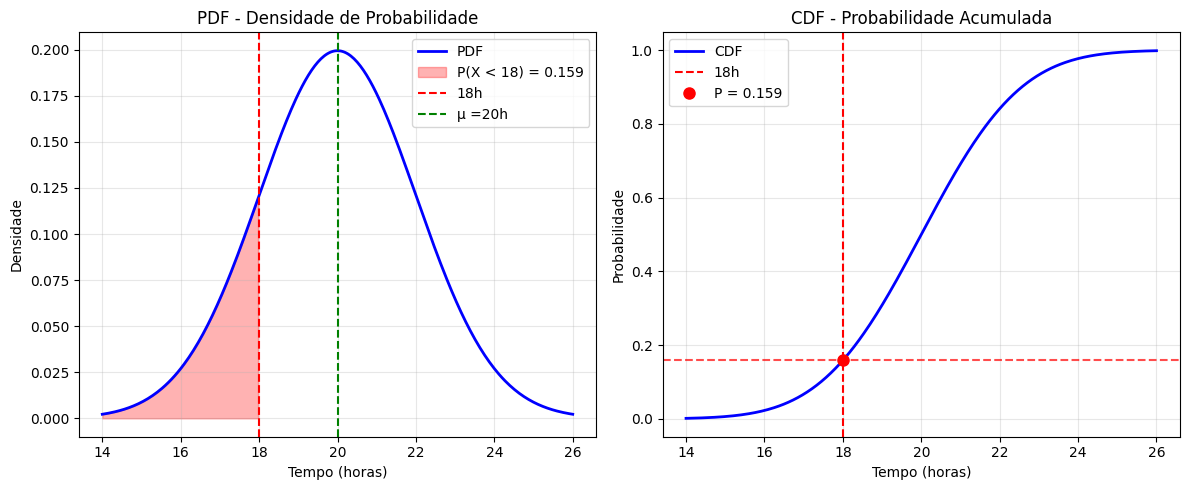

PDF em 18h: 12.10% (Densidade)
CDF em 18h: 15.87% (Probabilidade Acumulada)


In [14]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
media = 20
desvio_padrao = 2
tempo_limite = 18

# Cálculos
probabilidade_cdf = stats.norm.cdf(tempo_limite, loc=media, scale=desvio_padrao)
probabilidade_pdf = stats.norm.pdf(tempo_limite, loc=media, scale=desvio_padrao)

print(f"P(X < {tempo_limite})h = {probabilidade_cdf:.4f} ({probabilidade_cdf * 100:.2f}%)")

x = np.linspace(14, 26, 300)
pdf_y = stats.norm.pdf(x, loc=media, scale=desvio_padrao)
cdf_y = stats.norm.cdf(x, loc=media, scale=desvio_padrao)

# Cria gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico PDF
ax1.plot(x, pdf_y, 'b-', linewidth=2, label='PDF')
ax1.fill_between(x, pdf_y, where=(x <= tempo_limite), color='red', alpha=0.3, label=f'P(X < {tempo_limite}) = {probabilidade_cdf:.3f}')
ax1.axvline(tempo_limite, color='red', linestyle='--', label=f'{tempo_limite}h')
ax1.axvline(media, color="green", linestyle="--", label=f"μ ={media}h")
ax1.set_title('PDF - Densidade de Probabilidade')
ax1.set_xlabel('Tempo (horas)')
ax1.set_ylabel('Densidade')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico CDF
ax2.plot(x, cdf_y, 'b-', linewidth=2, label='CDF')
ax2.axhline(probabilidade_cdf, color='red', linestyle='--', alpha=0.7)
ax2.axvline(tempo_limite, color='red', linestyle='--', label=f'{tempo_limite}h')
ax2.plot(tempo_limite, probabilidade_cdf, 'ro', markersize=8, label=f'P = {probabilidade_cdf:.3f}')
ax2.set_title('CDF - Probabilidade Acumulada')
ax2.set_xlabel('Tempo (horas)')
ax2.set_ylabel('Probabilidade')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PDF em {tempo_limite}h: {probabilidade_pdf*100:.2f}% (Densidade)")
print(f"CDF em {tempo_limite}h: {probabilidade_cdf*100:.2f}% (Probabilidade Acumulada)")

## Exercício 2: Consumo de Combustível

O consumo de combustível (em km/l) de um determinado modelo de carro é normalmente distribuído com uma média de 12 km/l e um desvio padrão de 3 km/l.

Pergunta: Qual é a probabilidade de que um carro escolhido aleatoriamente tenha um consumo de combustível maior que 13 km/l?

 === CONSUMO DE COMBUSTÍVEL === 
Distribuição: Normal(μ=12, σ=3)
Pergunta: P(X > 13 km/l)

P( <= 13) = 0.6306
P(X > 13) = 1 - 0.6306 = 0.3694
Probabilidade: 36.94%

Z-score = (13 - 12) / 3 = 0.33


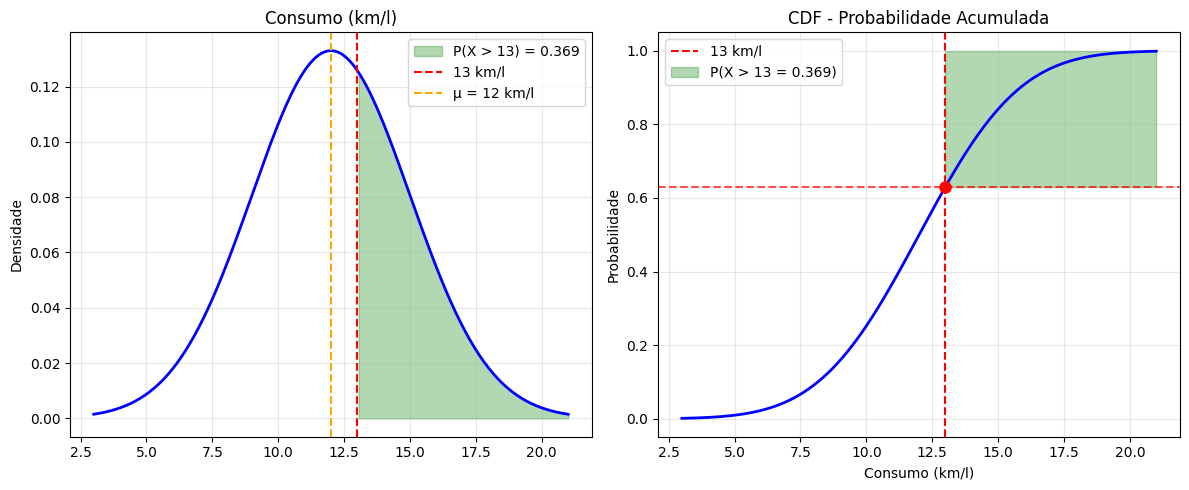


Resposta: 36.94% dos carros têm consumo > 13 km/l


In [17]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

media = 12
desvio_padrao = 3
limite = 13

print(" === CONSUMO DE COMBUSTÍVEL === ")
print(f"Distribuição: Normal(μ={media}, σ={desvio_padrao})")
print(f"Pergunta: P(X > {limite} km/l)")

prob_menor_igual = stats.norm.cdf(limite, loc=media, scale=desvio_padrao)
prob_maior = 1 - prob_menor_igual

print(f"\nP( <= {limite}) = {prob_menor_igual:.4f}")
print(f"P(X > {limite}) = 1 - {prob_menor_igual:.4f} = {prob_maior:.4f}")
print(f"Probabilidade: {prob_maior*100:.2f}%")

z_score = (limite - media) / desvio_padrao
print(f"\nZ-score = ({limite} - {media}) / {desvio_padrao} = {z_score:.2f}")

# Gráficos
x = np.linspace(3, 21, 300)
pdf_y = stats.norm.pdf(x, loc=media, scale=desvio_padrao)
cdf_y = stats.norm.cdf(x, loc=media, scale=desvio_padrao)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# PDF
ax1.plot(x, pdf_y, 'b-', linewidth=2)
ax1.fill_between(x, pdf_y, where=(x > limite), color='green', alpha=0.3, label=f'P(X > {limite}) = {prob_maior:.3f}')
ax1.axvline(limite, color='red', linestyle='--', label=f'{limite} km/l')
ax1.axvline(media, color="orange", linestyle="--", label=f'μ = {media} km/l')
ax1.set_title('PDF - Conumo > 13 km/l')
ax1.set_title('Consumo (km/l)')
ax1.set_ylabel('Densidade')
ax1.legend()
ax1.grid(True, alpha=0.3)

# CDF
ax2.plot(x, cdf_y, 'b-', linewidth=2)
ax2.axhline(prob_menor_igual, color='red', linestyle='--', alpha=0.7)
ax2.axvline(limite, color='red', linestyle='--', label=f'{limite} km/l')
ax2.plot(limite, prob_menor_igual, 'ro', markersize=8)
ax2.fill_between([limite, 21], [prob_menor_igual, prob_menor_igual], [1, 1], color='green', alpha=0.3, label=f'P(X > {limite} = {prob_maior:.3f})')
ax2.set_title('CDF - Probabilidade Acumulada')
ax2.set_xlabel('Consumo (km/l)')
ax2.set_ylabel('Probabilidade')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResposta: {prob_maior*100:.2f}% dos carros têm consumo > {limite} km/l")

Usaremos a função cdf (função de distribuição cumulativa) do objeto norm da biblioteca SciPy para calcular a probabilidade de um carro ter um consumo de combustível de até 13 km/l. A função cdf retorna a área sob a curva da distribuição normal até o ponto especificado (neste caso, 13 km/l), que representa a probabilidade acumulada. Para encontrar a probabilidade do consumo de combustível ser maior que 13 km/l, subtraímos essa probabilidade acumulada de 1.

A subtração de 1 da função de distribuição cumulativa (CDF) é uma técnica comum usada para calcular a probabilidade de que uma variável aleatória seja maior do que um certo valor em uma distribuição normal. Vamos entender isso com mais detalhes:

**norm.cdf(x, media, desvio_padrao)**: Esta função retorna a probabilidade de que uma variável aleatória seguindo uma distribuição normal com a média e o desvio padrão especificados seja menor ou igual a x. Em outras palavras, ela retorna a área sob a curva da distribuição normal até o ponto x.

**1 - norm.cdf(x, media, desvio_padrao)**: Como a área total sob a curva da distribuição normal é igual a 1, subtrair o valor da CDF de 1 dá a área sob a curva à direita de x. Isso equivale à probabilidade de que a variável aleatória seja maior do que x.

Portanto, ao usar **1 - norm.cdf(13, media, desvio_padrao)**, você está calculando a probabilidade de que a variável aleatória (neste caso, o consumo de combustível de um carro) seja maior do que 13 km/l. Essa abordagem é útil quando você está interessado em probabilidades do tipo "maior que" em uma distribuição normal.

<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
## Exercício 3: Peso dos Automóveis

O peso dos automóveis produzidos por uma fábrica segue uma distribuição normal com uma média de 1500 kg e um desvio padrão de 50 kg.

Pergunta: Qual é a probabilidade de que um automóvel produzido tenha um peso entre 1450 kg e 1550 kg?

 === PESO DOS AUTOMÓVEIS === 
Distribuição Normal: μ=1500, σ=50
Pergunta: P(1450 < x < 1550 kg)

P(X < 1550) = 0.8413
P(X < 1450 = 0.1587)
P(1450 < X < 1550) = 0.6827
Probabilidade: 68.27%

Z-scores: -1.0 e 1.0


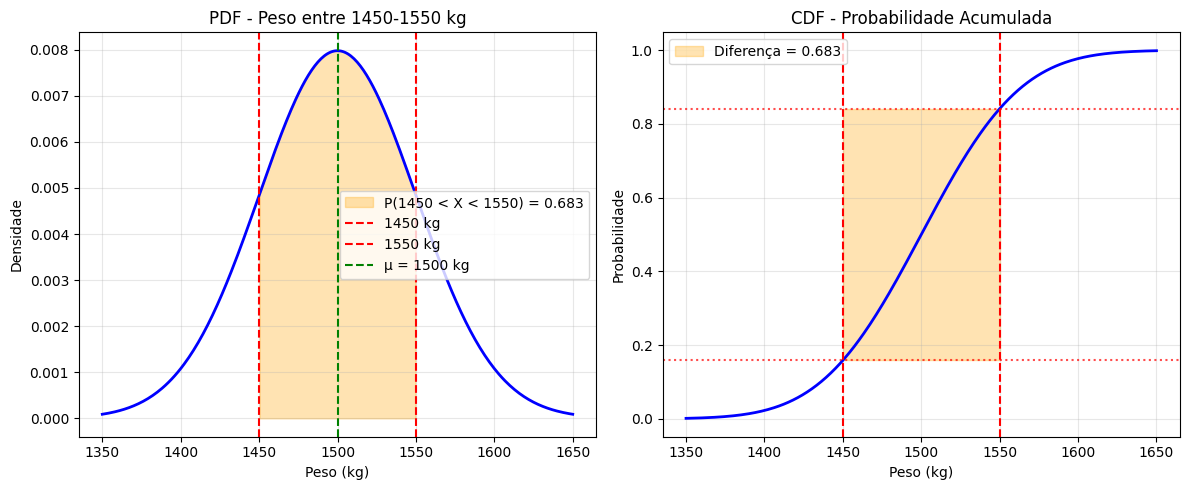

In [22]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

media = 1500
desvio_padrao= 50
limite_inferior = 1450
limite_superior = 1550

print(" === PESO DOS AUTOMÓVEIS === ")
print(f"Distribuição Normal: μ={media}, σ={desvio_padrao}")
print(f"Pergunta: P({limite_inferior} < x < {limite_superior} kg)")

prob_ate_1550 = stats.norm.cdf(limite_superior, loc=media, scale=desvio_padrao)
prob_ate_1450 = stats.norm.cdf(limite_inferior, loc=media, scale=desvio_padrao)
prob_entre = prob_ate_1550 - prob_ate_1450

print(f"\nP(X < {limite_superior}) = {prob_ate_1550:.4f}")
print(f"P(X < {limite_inferior} = {prob_ate_1450:.4f})")
print(f"P({limite_inferior} < X < {limite_superior}) = {prob_entre:.4f}")
print(f"Probabilidade: {prob_entre*100:.2f}%")

z1 = (limite_inferior - media) / desvio_padrao
z2 = (limite_superior - media) / desvio_padrao
print(f"\nZ-scores: {z1:.1f} e {z2:.1f}")

# Gráficos
x = np.linspace(1350, 1650, 300)
pdf_y = stats.norm.pdf(x, loc=media, scale=desvio_padrao)
cdf_y = stats.norm.cdf(x, loc=media, scale=desvio_padrao)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# PDF
ax1.plot(x, pdf_y, 'b-', linewidth=2)
ax1.fill_between(x, pdf_y, where=((x >= limite_inferior) & (x <= limite_superior)),
                 color='orange', alpha=0.3, label=f'P({limite_inferior} < X < {limite_superior}) = {prob_entre:.3f}')
ax1.axvline(limite_inferior, color='red', linestyle='--', label=f'{limite_inferior} kg')
ax1.axvline(limite_superior, color='red', linestyle='--', label=f'{limite_superior} kg')
ax1.axvline(media, color='green', linestyle='--', label=f'μ = {media} kg')
ax1.set_title('PDF - Peso entre 1450-1550 kg')
ax1.set_xlabel('Peso (kg)')
ax1.set_ylabel('Densidade')
ax1.legend()
ax1.grid(True, alpha=0.3)

# CDF
ax2.plot(x, cdf_y, 'b-', linewidth=2)
ax2.axhline(prob_ate_1450, color='red', linestyle=':', alpha=0.7)
ax2.axhline(prob_ate_1550, color='red', linestyle=':', alpha=0.7)
ax2.axvline(limite_inferior, color='red', linestyle='--')
ax2.axvline(limite_superior, color='red', linestyle='--')
ax2.fill_between([limite_inferior, limite_superior], [prob_ate_1450, prob_ate_1450], [prob_ate_1550, prob_ate_1550], color='orange', alpha=0.3, label=f'Diferença = {prob_entre:.3f}')
ax2.set_title('CDF - Probabilidade Acumulada')
ax2.set_xlabel('Peso (kg)')
ax2.set_ylabel('Probabilidade')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Exemplo 4: Nota Média na Prova

Suponha que as notas de uma prova em uma turma sigam uma distribuição normal com uma média de 70 e um desvio padrão de 12.

Pergunta: Qual é a probabilidade de que um aluno escolhido aleatoriamente tenha uma nota maior que 80?

 === NOTAS DA PROVA === 
Distribuição: Normal(μ=70, σ=12)
Pergunta: P(X > 80)

P(X <= 80) = 0.7977
P(X > 80) = 1 - 0.7977 = 0.2023
Probabilidade: 20.23

Z-score = (80 - 70) / 12 = 0.83


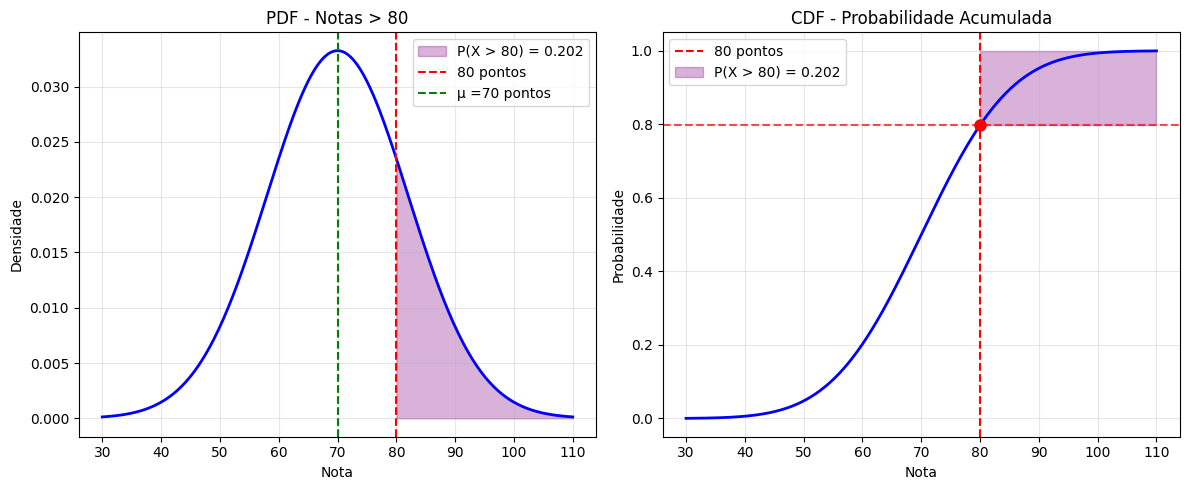


Resposta: 20.23% dos alunos tiram nota > 80


In [27]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

media = 70
desvio_padrao = 12
limite = 80

print(" === NOTAS DA PROVA === ")
print(f"Distribuição: Normal(μ={media}, σ={desvio_padrao})")
print(f"Pergunta: P(X > {limite})")

prob_ate_80 = stats.norm.cdf(limite, loc=media, scale=desvio_padrao)
prob_maior_80 = 1 - prob_ate_80

print(f"\nP(X <= {limite}) = {prob_ate_80:.4f}")
print(f"P(X > {limite}) = 1 - {prob_ate_80:.4f} = {prob_maior_80:.4f}")
print(f"Probabilidade: {prob_maior_80*100:.2f}")

z_score = (limite - media) / desvio_padrao
print(f"\nZ-score = ({limite} - {media}) / {desvio_padrao} = {z_score:.2f}")

# Gráficos
x = np.linspace(30, 110, 300)
pdf_y = stats.norm.pdf(x, loc=media, scale=desvio_padrao)
cdf_y = stats.norm.cdf(x, loc=media, scale=desvio_padrao)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# PDF
ax1.plot(x, pdf_y, 'b-', linewidth=2)
ax1.fill_between(x, pdf_y, where=(x > limite), color='purple', alpha=0.3, label=f'P(X > {limite}) = {prob_maior_80:.3f}')
ax1.axvline(limite, color='red', linestyle='--', label=f'{limite} pontos')
ax1.axvline(media, color='green', linestyle='--', label=f'μ ={media} pontos')
ax1.set_title('PDF - Notas > 80')
ax1.set_xlabel('Nota')
ax1.set_ylabel('Densidade')
ax1.legend()
ax1.grid(True, alpha=0.3)

# CDF
ax2.plot(x, cdf_y, 'b-', linewidth=2)
ax2.axhline(prob_ate_80, color='red', linestyle='--', alpha=0.7)
ax2.axvline(limite, color='red', linestyle='--', label=f'{limite} pontos')
ax2.plot(limite, prob_ate_80, 'ro', markersize=8)
ax2.fill_between([limite, 110], [prob_ate_80, prob_ate_80], [1, 1], color='purple', alpha=0.3, label=f'P(X > {limite}) = {prob_maior_80:.3f}')
ax2.set_title('CDF - Probabilidade Acumulada')
ax2.set_xlabel('Nota')
ax2.set_ylabel('Probabilidade')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResposta: {prob_maior_80*100:.2f}% dos alunos tiram nota > {limite}")

## Exemplo 5: Notas de Aprovação

As notas finais de uma turma em uma disciplina específica são normalmente distribuídas com uma média de 60 e um desvio padrão de 15.

Pergunta: Qual é a probabilidade de que um aluno escolhido aleatoriamente tenha uma nota final entre 50 e 70?

 === NOTA DE APROVAÇÃO === 
Distribuição Normal: (μ=60, σ=15)
Pergunta: P(50 < x < 70)

P(X < 70) = 0.7475
P(X < 50) = 0.2525
P(50 < X < 70) = 0.4950
Probabilidade: 49.50%

Z-scores: -0.67 e 0.67


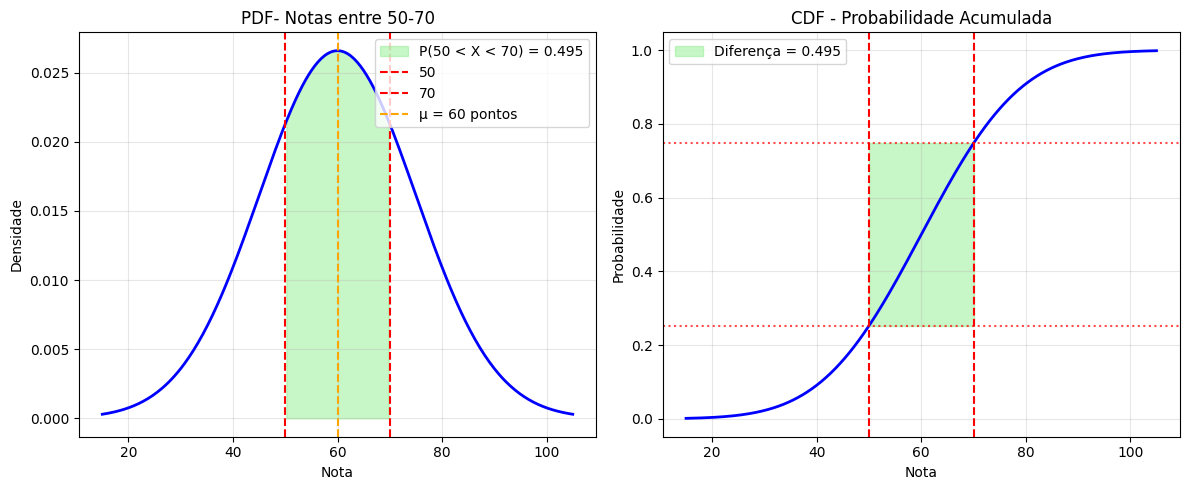


Resposta: 49.50% dos alunos têm nota entre 50-70


In [29]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

media = 60
desvio_padrao = 15
limite_inferior = 50
limite_superior = 70

print(" === NOTA DE APROVAÇÃO === ")
print(f"Distribuição Normal: (μ={media}, σ={desvio_padrao})")
print(f"Pergunta: P({limite_inferior} < x < {limite_superior})")

prob_ate_70 = stats.norm.cdf(limite_superior, loc=media, scale=desvio_padrao)
prob_ate_50 = stats.norm.cdf(limite_inferior, loc=media, scale=desvio_padrao)
prob_entre = prob_ate_70 - prob_ate_50

print(f"\nP(X < {limite_superior}) = {prob_ate_70:.4f}")
print(f"P(X < {limite_inferior}) = {prob_ate_50:.4f}")
print(f"P({limite_inferior} < X < {limite_superior}) = {prob_entre:.4f}")
print(f"Probabilidade: {prob_entre*100:.2f}%")

z1 = (limite_inferior - media) / desvio_padrao
z2 = (limite_superior - media) / desvio_padrao
print(f"\nZ-scores: {z1:.2f} e {z2:.2f}")

# Gráficos
x = np.linspace(15, 105, 300)
pdf_y = stats.norm.pdf(x, loc=media, scale=desvio_padrao)
cdf_y = stats.norm.cdf(x, loc=media, scale=desvio_padrao)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# PDF
ax1.plot(x, pdf_y, 'b-', linewidth=2)
ax1.fill_between(x, pdf_y, where=((x >= limite_inferior) & (x <= limite_superior)),
                 color='lightgreen', alpha=0.5, label=f'P({limite_inferior} < X < {limite_superior}) = {prob_entre:.3f}')
ax1.axvline(limite_inferior, color='red', linestyle='--', label=f'{limite_inferior}')
ax1.axvline(limite_superior, color='red', linestyle='--', label=f'{limite_superior}')
ax1.axvline(media, color='orange', linestyle='--', label=f'μ = {media} pontos')
ax1.set_title('PDF- Notas entre 50-70')
ax1.set_xlabel('Nota')
ax1.set_ylabel('Densidade')
ax1.legend()
ax1.grid(True, alpha=0.3)

# CDF
ax2.plot(x, cdf_y, 'b-', linewidth=2)
ax2.axhline(prob_ate_50, color='red', linestyle=':', alpha=0.7)
ax2.axhline(prob_ate_70, color='red', linestyle=':', alpha=0.7)
ax2.axvline(limite_inferior, color='red', linestyle='--')
ax2.axvline(limite_superior, color='red', linestyle='--')
ax2.fill_between([limite_inferior, limite_superior], [prob_ate_50, prob_ate_50], [prob_ate_70, prob_ate_70], color='lightgreen', alpha=0.5, label=f'Diferença = {prob_entre:.3f}')
ax2.set_title('CDF - Probabilidade Acumulada')
ax2.set_xlabel('Nota')
ax2.set_ylabel('Probabilidade')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResposta: {prob_entre*100:.2f}% dos alunos têm nota entre {limite_inferior}-{limite_superior}")